# Phase 1 — Sensibilité au plafond RUL (test H4)

Objectif : le plafond RUL (125) est un choix méthodologique, pas une valeur imposée par les
données. On refait l'entraînement du LSTM avec trois plafonds (110, 125, 140) pour voir si la
conclusion du mémoire dépend fortement de ce choix précis.

**Sur le val, pas le test** : `test_FD001.txt` a été ouvert une seule fois dans
`07_final_test_fd001.ipynb` et ce résultat est déjà rapporté. Le rouvrir ici pour comparer des
variantes d'hyperparamètre reviendrait à s'en servir pour du réglage, ce que le protocole
interdit explicitement. Cette analyse porte donc sur les 20 moteurs val, avec le même split
(seed=42) que tous les notebooks précédents.

**Seed du modèle fixée (42)** pour les trois plafonds : on veut isoler l'effet du plafond,
pas le mélanger avec la variance déjà mesurée dans `06_lstm_seed_variance.ipynb`.

Critère « fait » (plan d'exécution, Phase 1) : effet du plafond rapporté (test H4).

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.metrics import asymmetric_score, rmse
from src.preprocessing import add_piecewise_rul, compute_norm_stats, make_windows, normalize, select_features, split_by_unit
from src.torch_model import RULRegressor, set_seed, train_model

SEED = 42
WINDOW_SIZE = 30
CAPS = [110, 125, 140]

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

raw = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None)
raw = raw.iloc[:, : len(COL_NAMES)]
raw.columns = COL_NAMES

train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SEED)
selected_sensors = select_features(train_raw, SENSOR_NAMES, std_threshold=1e-2)
norm_stats = compute_norm_stats(train_raw, selected_sensors)

# Le plafond ne change que la cible RUL, pas les capteurs : la normalisation des features
# ne dépend pas du plafond, donc train_norm/val_norm sont calculés une seule fois ici.
train_norm = normalize(train_raw, selected_sensors, norm_stats)
val_norm = normalize(val_raw, selected_sensors, norm_stats)

In [2]:
rows = []

for cap in CAPS:
    train_rul = add_piecewise_rul(train_norm, cap=cap)
    val_rul = add_piecewise_rul(val_norm, cap=cap)

    X_train, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
    X_val, y_val, _ = make_windows(val_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")

    set_seed(SEED)  # même graine pour les 3 plafonds : on isole l'effet du plafond
    model = RULRegressor(n_features=len(selected_sensors), hidden_size=64)
    model, _ = train_model(model, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3, batch_size=64, seed=SEED)

    model.eval()
    with torch.no_grad():
        device = next(model.parameters()).device
        y_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()

    rows.append({
        "plafond": cap,
        "RMSE": rmse(y_val, y_pred),
        "score_asymétrique": asymmetric_score(y_val, y_pred),
    })
    print(f"plafond {cap} : RMSE={rows[-1]['RMSE']:.3f}, score_asymétrique={rows[-1]['score_asymétrique']:.1f}")

cap_results = pd.DataFrame(rows)
cap_results

plafond 110 : RMSE=10.775, score_asymétrique=7705.0


plafond 125 : RMSE=13.088, score_asymétrique=12245.1


plafond 140 : RMSE=15.487, score_asymétrique=22297.2


,plafond,RMSE,score_asymétrique
0,110,10.775280,7705.006433
1,125,13.088298,12245.140782
2,140,15.486767,22297.190658


In [3]:
# RMSE / plafond : normalise par l'échelle de cible pour voir si l'erreur RELATIVE se dégrade
# vraiment, ou si l'augmentation brute du RMSE n'est qu'un effet mécanique de l'échelle.
cap_results["RMSE_relatif"] = cap_results["RMSE"] / cap_results["plafond"]
cap_results

,plafond,RMSE,score_asymétrique,RMSE_relatif
0,110,10.775280,7705.006433,0.097957
1,125,13.088298,12245.140782,0.104706
2,140,15.486767,22297.190658,0.110620


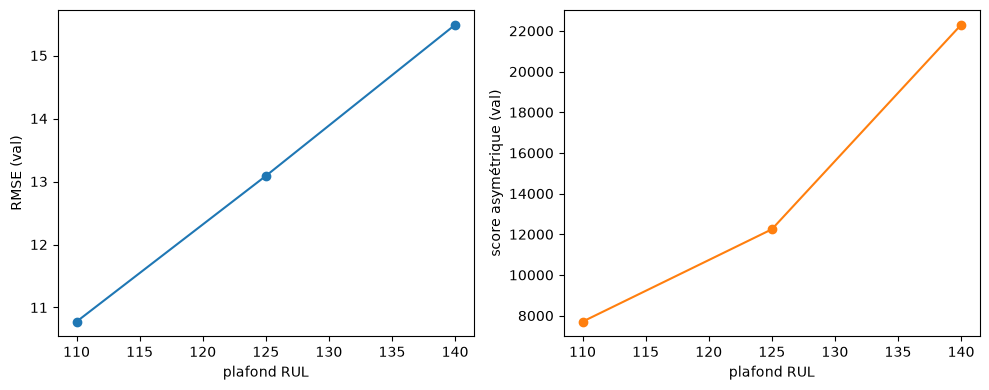

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(cap_results["plafond"], cap_results["RMSE"], marker="o")
axes[0].set_xlabel("plafond RUL")
axes[0].set_ylabel("RMSE (val)")

axes[1].plot(cap_results["plafond"], cap_results["score_asymétrique"], marker="o", color="tab:orange")
axes[1].set_xlabel("plafond RUL")
axes[1].set_ylabel("score asymétrique (val)")

fig.tight_layout()

**Ce que montrent ces figures** : l'effet du plafond sur les deux métriques, sur les mêmes 20
moteurs val, même seed. **Précaution de lecture** : augmenter le plafond élargit aussi l'échelle
de la cible (0 à 140 au lieu de 0 à 110), donc une partie d'un éventuel RMSE plus élevé peut
venir de cette échelle plus large, pas seulement d'une prédiction "moins bonne" au sens strict.
Ce qui compte ici n'est pas la valeur absolue de chaque point, mais la **taille de l'écart**
entre 110, 125 et 140 : un écart faible confirmerait que la conclusion du mémoire (le LSTM bat
la baseline) ne dépend pas d'un choix arbitraire de plafond ; un écart important obligerait à
documenter le plafond comme un hyperparamètre sensible, à justifier plus longuement.